<a href="https://colab.research.google.com/github/Ash3rC/Works/blob/main/Plots_and_Graphs_HSL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import xgboost as xgb
from xgboost import XGBRegressor, XGBClassifier
from sklearn.metrics import (
    mean_squared_error, r2_score,
    classification_report, confusion_matrix,
    roc_curve, roc_auc_score,
    precision_recall_curve, auc
)
import shap

from google.colab import drive

In [ ]:
from google.colab import files

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

hsl = pd.read_csv('/content/drive/MyDrive/HSL_Lake_ML_Data.csv')

Mounted at /content/drive


In [ ]:
hsl['Date'] = pd.to_datetime(hsl['Date'])
hsl = hsl.sort_values('Date').reset_index(drop=True)

hsl.columns = [
    'Date', 'NDCI', 'NDTI', 'SDD',
    'NO2', 'SO2', 'O3', 'CO', 'Aerosol_Index',
    'TMax', 'TMin', 'RH', 'Rainfall',
    'Wind_Speed', 'Wind_Gust', 'Wind_Direction',
    'Sunshine_Duration', 'PET', 'Cloud_Cover', 'Soil_Moisture'
]

Regression: Modeling Chlorophyll Dynamics
Train/Test split model fit

In [ ]:
train = hsl[hsl['Date'] < '2024-01-01']
test = hsl[hsl['Date'] >= '2024-01-01']

x_train = train.drop(columns=['Date','NDCI','NDTI','SDD'])
y_train = train['NDCI']
x_test = test.drop(columns=['Date','NDCI','NDTI','SDD'])
y_test = test['NDCI']

model = XGBRegressor(n_estimators=100, learning_rate=.1, random_state=42)
model.fit(x_train, y_train)
predictions = model.predict(x_test)
y_pred = model.predict(x_test)

Regression Metrics: RMSE, R^2

In [ ]:
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)
print(f"RMSE: {rmse}")
print(f"R2: {r2}")

RMSE: 0.06010337610234583
R2: 0.5826170062322606


Predicted vs Actual NDCI (validation plot, 1:1 line, R^2/RMSE annotation)

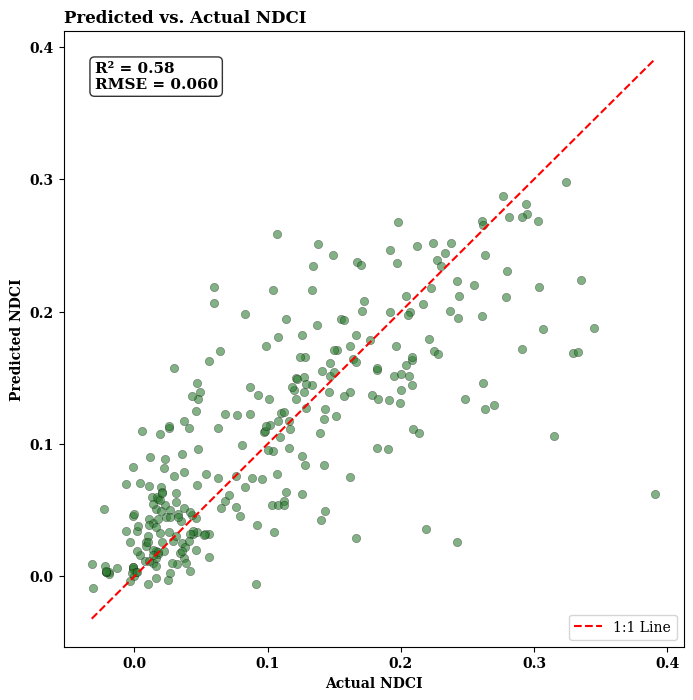

In [ ]:
plt.rcParams['font.family'] = 'serif'

fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(y_test, predictions, alpha=0.6, color='#2E7D32', edgecolor='black', linewidth=0.3)

min_val = min(y_test.min(), predictions.min())
max_val = max(y_test.max(), predictions.max())
ax.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=1.5, label='1:1 Line')

ax.set_xlabel('Actual NDCI', fontweight='bold')
ax.set_ylabel('Predicted NDCI', fontweight='bold')
ax.set_title('Predicted vs. Actual NDCI', fontweight='bold', loc='left')
ax.legend()
ax.grid(False)

ax.tick_params(axis='both', labelsize=10)
plt.setp(ax.get_xticklabels(), fontweight='bold')
plt.setp(ax.get_yticklabels(), fontweight='bold')
ax.text(0.05, 0.95, f'R² = {r2:.2f}\nRMSE = {rmse:.3f}', transform=ax.transAxes,
        fontsize=11, fontweight='bold', verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.savefig('regression_validation_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

SHAP Set

In [ ]:
plt.rcParams['font.family'] = 'serif'
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(x_test)

# x_test_display = x_test.copy()
# x_test_display.columns = [col.replace('_', ' ') for col in x_test_display.columns]

# shap.summary_plot(shap_values, x_test_display, show=False)

# ax = plt.gca()
# ax.set_facecolor('white')
# ax.grid(False)

# for label in ax.get_yticklabels():
#     label.set_fontweight('bold')
# for label in ax.get_xticklabels():
#     label.set_fontweight('bold')

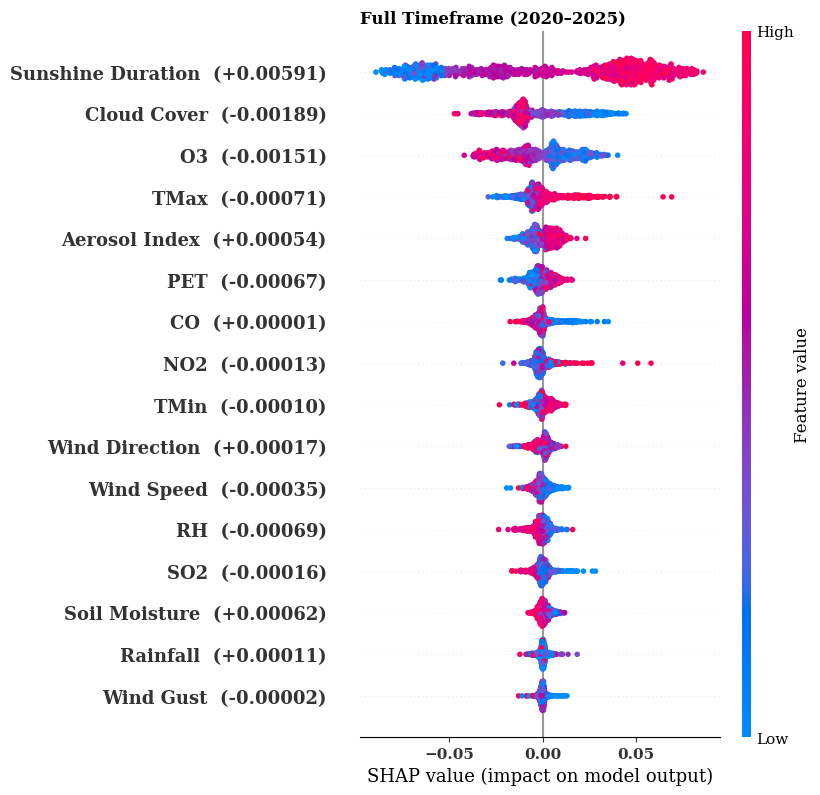

In [ ]:
X_full = hsl[x_test.columns]
X_full_display = X_full.copy()

shap_values_full = explainer.shap_values(X_full)

mean_shap = shap_values_full.mean(axis=0)

new_labels = []
for col, val in zip(X_full.columns, mean_shap):
    clean_name = col.replace('_', ' ')
    new_labels.append(f"{clean_name}  ({val:+.5f})")

X_full_display.columns = new_labels

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_full, X_full_display, show=False)
ax = plt.gca()
ax.grid(False)
plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')
plt.title('Full Timeframe (2020–2025)', fontweight='bold', fontsize=12, loc='left')
plt.savefig('shap_regression_full.png', dpi=300, bbox_inches='tight')
plt.show()

Residual Plot

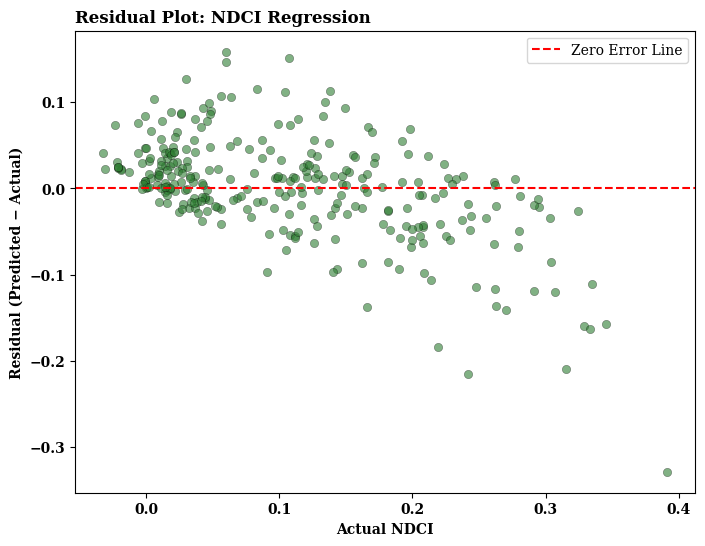

In [ ]:
plt.rcParams['font.family'] = 'serif'

residuals = predictions - y_test

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(y_test, residuals, alpha=0.6, color='#2E7D32', edgecolor='black', linewidth=0.3)
ax.axhline(y=0, color='red', linestyle='--', linewidth=1.5, label='Zero Error Line')

ax.set_xlabel('Actual NDCI', fontweight='bold')
ax.set_ylabel('Residual (Predicted − Actual)', fontweight='bold')
ax.set_title('Residual Plot: NDCI Regression', fontweight='bold', loc='left')
ax.legend()
ax.grid(False)

plt.setp(ax.get_xticklabels(), fontweight='bold')
plt.setp(ax.get_yticklabels(), fontweight='bold')

plt.savefig('regression_residual_plot.png', dpi=300, bbox_inches='tight')
plt.show()

Modeling Bloom Events: Classification

In [ ]:
hsl['Bloom'] = np.where(hsl['NDCI'] >= .2, 1, 0)

ctrain = hsl[hsl['Date'] < '2024-01-01']
ctest = hsl[hsl['Date'] >= '2024-01-01']
cx_train = ctrain.drop(columns=['Date','NDCI','NDTI','SDD', 'Bloom'])
cy_train = ctrain['Bloom']
cx_test = ctest.drop(columns=['Date','NDCI','NDTI','SDD', 'Bloom'])
cy_test = ctest['Bloom']

cmodel = XGBClassifier(scale_pos_weight=4.42, n_estimators=100, learning_rate=.1, random_state=42)
cmodel.fit(cx_train, cy_train)

cprob = cmodel.predict_proba(cx_test)[:, 1]
cpred_adjusted = (cprob >= 0.3).astype(int)

In [ ]:
print(classification_report(cy_test, cpred_adjusted))
print(confusion_matrix(cy_test, cpred_adjusted))

              precision    recall  f1-score   support

           0       0.92      0.86      0.89       236
           1       0.54      0.70      0.61        56

    accuracy                           0.83       292
   macro avg       0.73      0.78      0.75       292
weighted avg       0.85      0.83      0.84       292

[[203  33]
 [ 17  39]]


Confusion Matrix

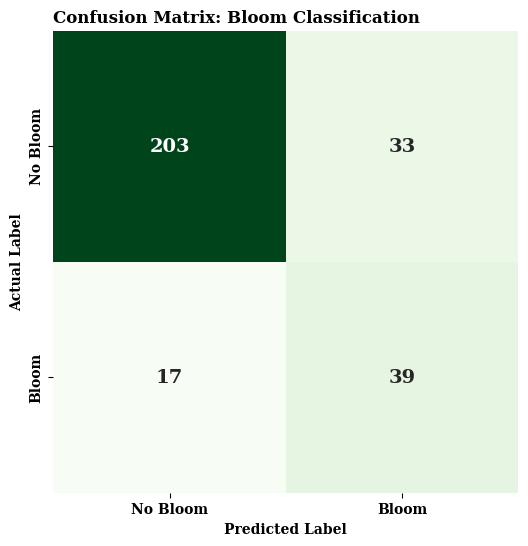

In [ ]:
plt.rcParams['font.family'] = 'serif'

cm = confusion_matrix(cy_test, cpred_adjusted)

fig, ax = plt.subplots(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['No Bloom', 'Bloom'], yticklabels=['No Bloom', 'Bloom'],
            annot_kws={'fontweight': 'bold', 'fontsize': 14}, ax=ax)

ax.set_xlabel('Predicted Label', fontweight='bold')
ax.set_ylabel('Actual Label', fontweight='bold')
ax.set_title('Confusion Matrix: Bloom Classification', fontweight='bold', loc='left')

plt.setp(ax.get_xticklabels(), fontweight='bold')
plt.setp(ax.get_yticklabels(), fontweight='bold')

plt.savefig('classification_validation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

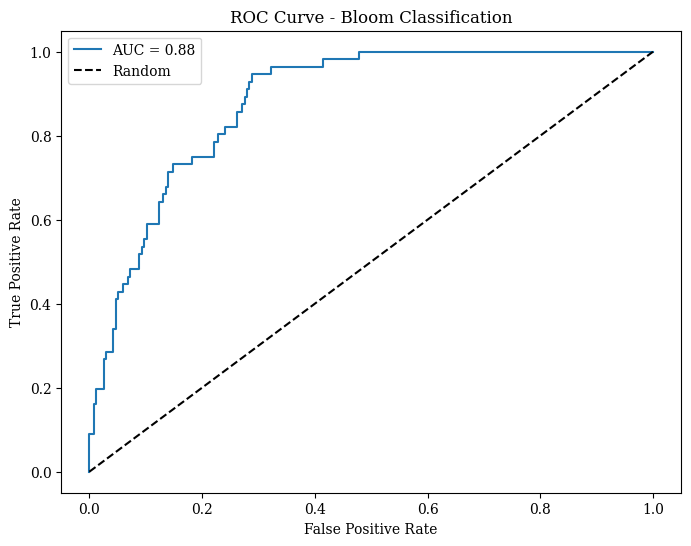

In [ ]:
fpr, tpr, _ = roc_curve(cy_test, cprob)
roc_auc = roc_auc_score(cy_test, cprob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Bloom Classification')
plt.legend()
plt.show()

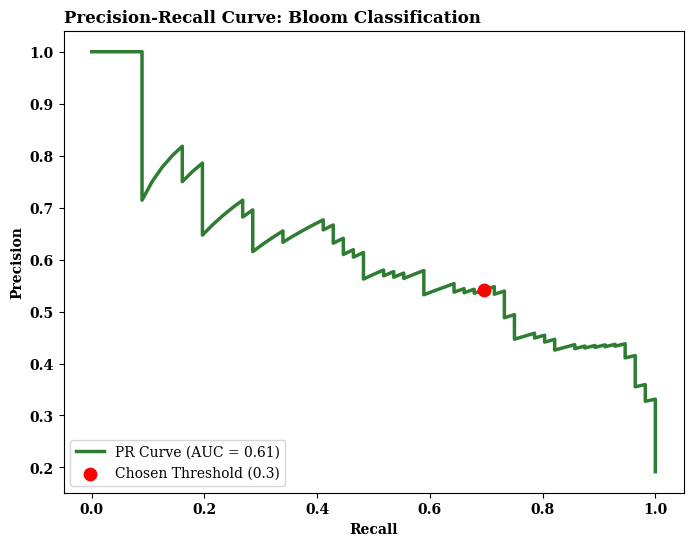

In [ ]:
plt.rcParams['font.family'] = 'serif'

precision_vals, recall_vals, thresholds = precision_recall_curve(cy_test, cprob)
pr_auc = auc(recall_vals, precision_vals)

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(recall_vals, precision_vals, color='#2E7D32', linewidth=2.5, label=f'PR Curve (AUC = {pr_auc:.2f})')

idx = (np.abs(thresholds - 0.3)).argmin()
ax.scatter(recall_vals[idx], precision_vals[idx], color='red', s=80, zorder=5,
           label='Chosen Threshold (0.3)')

ax.set_xlabel('Recall', fontweight='bold')
ax.set_ylabel('Precision', fontweight='bold')
ax.set_title('Precision-Recall Curve: Bloom Classification', fontweight='bold', loc='left')
ax.legend(loc='lower left')
ax.grid(False)

plt.setp(ax.get_xticklabels(), fontweight='bold')
plt.setp(ax.get_yticklabels(), fontweight='bold')

plt.savefig('classification_pr_curve.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
cexplainer = shap.TreeExplainer(cmodel)
cshap_values = cexplainer.shap_values(cx_test)

cx_test_display = cx_test.copy()
cx_test_display.columns = [col.replace('_', ' ') for col in cx_test_display.columns]

mean_shap_by_feature_c = dict(zip(cx_test_display.columns, cshap_values.mean(axis=0)))

# shap.summary_plot(cshap_values, cx_test_display, show=False)

# ax = plt.gca()
# ax.set_facecolor('white')
# ax.grid(False)

# new_labels = []
# for label in ax.get_yticklabels():
#     feature_name = label.get_text()
#     mean_val = mean_shap_by_feature_c.get(feature_name, 0)
#     sign = '+' if mean_val >= 0 else ''
#     new_labels.append(f"{feature_name}  ({sign}{mean_val:.3f})")
# ax.set_yticklabels(new_labels, fontweight='bold')

# for label in ax.get_xticklabels():
#     label.set_fontweight('bold')

# plt.gcf().set_facecolor('white')
# plt.savefig('cshap_summary.png', dpi=300, bbox_inches='tight')
# plt.show()

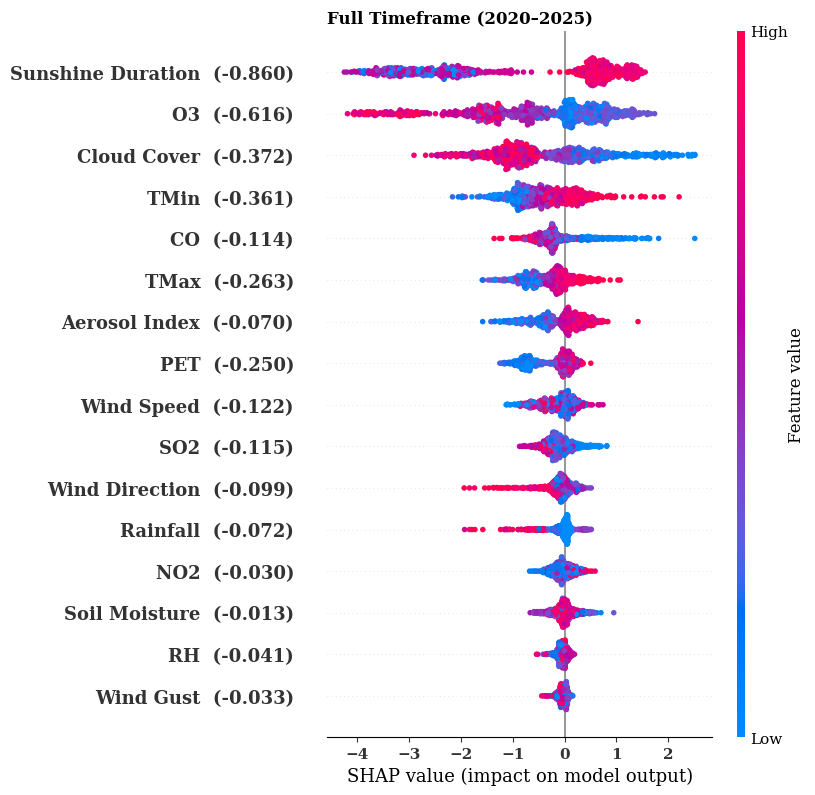

In [ ]:
X_cfull = hsl[cx_test.columns]
X_cfull_display = X_cfull.copy()

cshap_values_full = cexplainer.shap_values(X_cfull)

cmean_shap = cshap_values_full.mean(axis=0)

cnew_labels = []
for col, val in zip(X_cfull.columns, cmean_shap):
    clean_name = col.replace('_', ' ')
    cnew_labels.append(f"{clean_name}  ({val:+.3f})")

X_cfull_display.columns = cnew_labels

plt.figure(figsize=(10, 8))
shap.summary_plot(cshap_values_full, X_cfull_display, show=False)
ax = plt.gca()
ax.grid(False)
plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')
plt.title('Full Timeframe (2020–2025)', fontweight='bold', fontsize=12, loc='left')
plt.savefig('shap_classification_full.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# plt.rcParams['font.family'] = 'serif'

# fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# # Panel 1: Actual vs Predicted
# axes[0].scatter(y_test, predictions, alpha=0.6, color='#2E7D32', edgecolor='black', linewidth=0.3)
# min_val = min(y_test.min(), predictions.min())
# max_val = max(y_test.max(), predictions.max())
# axes[0].plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=1.5)
# axes[0].set_xlabel('Actual NDCI', fontweight='bold')
# axes[0].set_ylabel('Predicted NDCI', fontweight='bold')
# axes[0].set_title(f'Test Set: Actual vs Predicted\nR² = {r2:.3f}', fontweight='bold')
# axes[0].grid(False)

# # Panel 2: Residuals
# residuals = y_test - predictions
# axes[1].scatter(predictions, residuals, alpha=0.6, color='#2E7D32', edgecolor='black', linewidth=0.3)
# axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1.5)
# axes[1].set_xlabel('Predicted NDCI', fontweight='bold')
# axes[1].set_ylabel('Residual (Actual − Predicted)', fontweight='bold')
# axes[1].set_title('Residuals (Test Set)', fontweight='bold')
# axes[1].grid(False)

# # Panel 3: Feature Importance
# importance = model.get_booster().get_score(importance_type='gain')
# importance_df = pd.DataFrame(list(importance.items()), columns=['Feature', 'Importance'])
# importance_df['Feature'] = importance_df['Feature'].str.replace('_', ' ')
# importance_df = importance_df.sort_values('Importance', ascending=True)

# axes[2].barh(importance_df['Feature'], importance_df['Importance'], color='#2E7D32')
# axes[2].set_xlabel('Importance', fontweight='bold')
# axes[2].set_title('Feature Importance (Gain-Based)', fontweight='bold')
# axes[2].grid(False)

# for ax in axes:
#     plt.setp(ax.get_xticklabels(), fontweight='bold')
#     plt.setp(ax.get_yticklabels(), fontweight='bold')

# plt.tight_layout()
# plt.savefig('regression_combined_validation.png', dpi=300, bbox_inches='tight')
# files.download('regression_combined_validation.png')
# plt.show()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

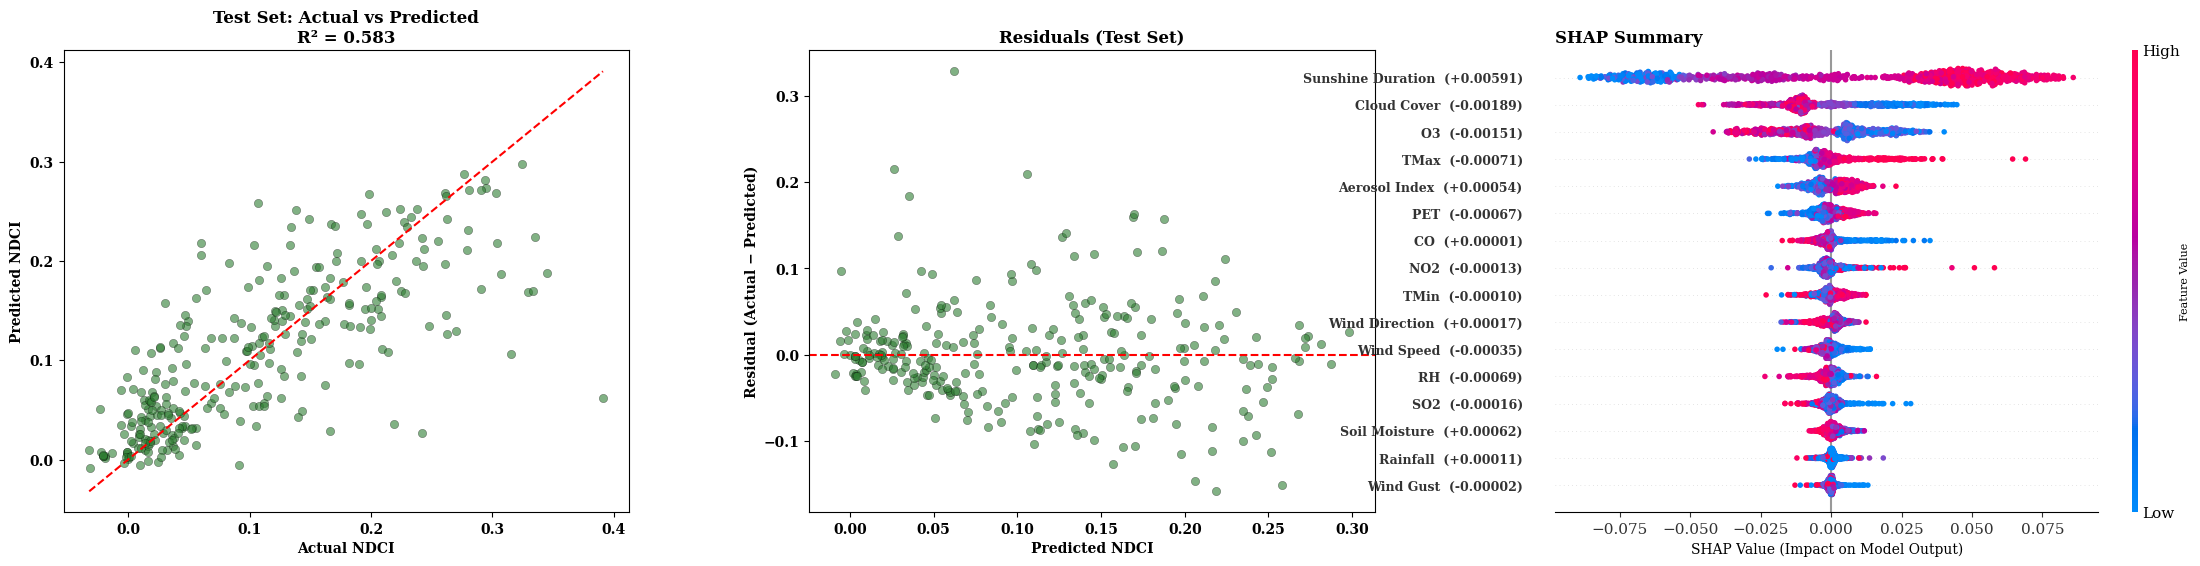

In [ ]:
plt.rcParams['font.family'] = 'serif'

fig = plt.figure(figsize=(28, 6))
gs = gridspec.GridSpec(1, 3, width_ratios=[1, 1, 1.2], wspace=0.3)
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
ax3 = fig.add_subplot(gs[2])

# Panel 1: Actual vs Predicted
ax1.scatter(y_test, predictions, alpha=0.6, color='#2E7D32', edgecolor='black', linewidth=0.3)
min_val = min(y_test.min(), predictions.min())
max_val = max(y_test.max(), predictions.max())
ax1.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=1.5)
ax1.set_xlabel('Actual NDCI', fontweight='bold')
ax1.set_ylabel('Predicted NDCI', fontweight='bold')
ax1.set_title(f'Test Set: Actual vs Predicted\nR² = {r2:.3f}', fontweight='bold')
ax1.grid(False)

# Panel 2: Residuals
residuals = y_test - predictions
ax2.scatter(predictions, residuals, alpha=0.6, color='#2E7D32', edgecolor='black', linewidth=0.3)
ax2.axhline(y=0, color='red', linestyle='--', linewidth=1.5)
ax2.set_xlabel('Predicted NDCI', fontweight='bold')
ax2.set_ylabel('Residual (Actual − Predicted)', fontweight='bold')
ax2.set_title('Residuals (Test Set)', fontweight='bold')
ax2.grid(False)

# Panel 3: SHAP Summary (replaces gain-based feature importance)
plt.sca(ax3)
shap.summary_plot(shap_values_full, X_full_display, show=False, plot_size=None)
ax3.set_title('SHAP Summary', fontweight='bold', loc='left')
ax3.set_xlabel('SHAP Value (Impact on Model Output)', fontsize=10)
plt.setp(ax3.get_yticklabels(), fontweight='bold', fontsize=9)

for ax in [ax1, ax2]:
    plt.setp(ax.get_xticklabels(), fontweight='bold')
    plt.setp(ax.get_yticklabels(), fontweight='bold')

for extra_ax in fig.axes:
    if extra_ax not in (ax1, ax2, ax3):
        extra_ax.set_ylabel('Feature Value', fontsize=8)
        pos = extra_ax.get_position()
        extra_ax.set_position([pos.x0, pos.y0, pos.width * 0.8, pos.height])

plt.savefig('regression_combined_validation.png', dpi=300, bbox_inches='tight')
files.download('regression_combined_validation.png')
plt.show()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

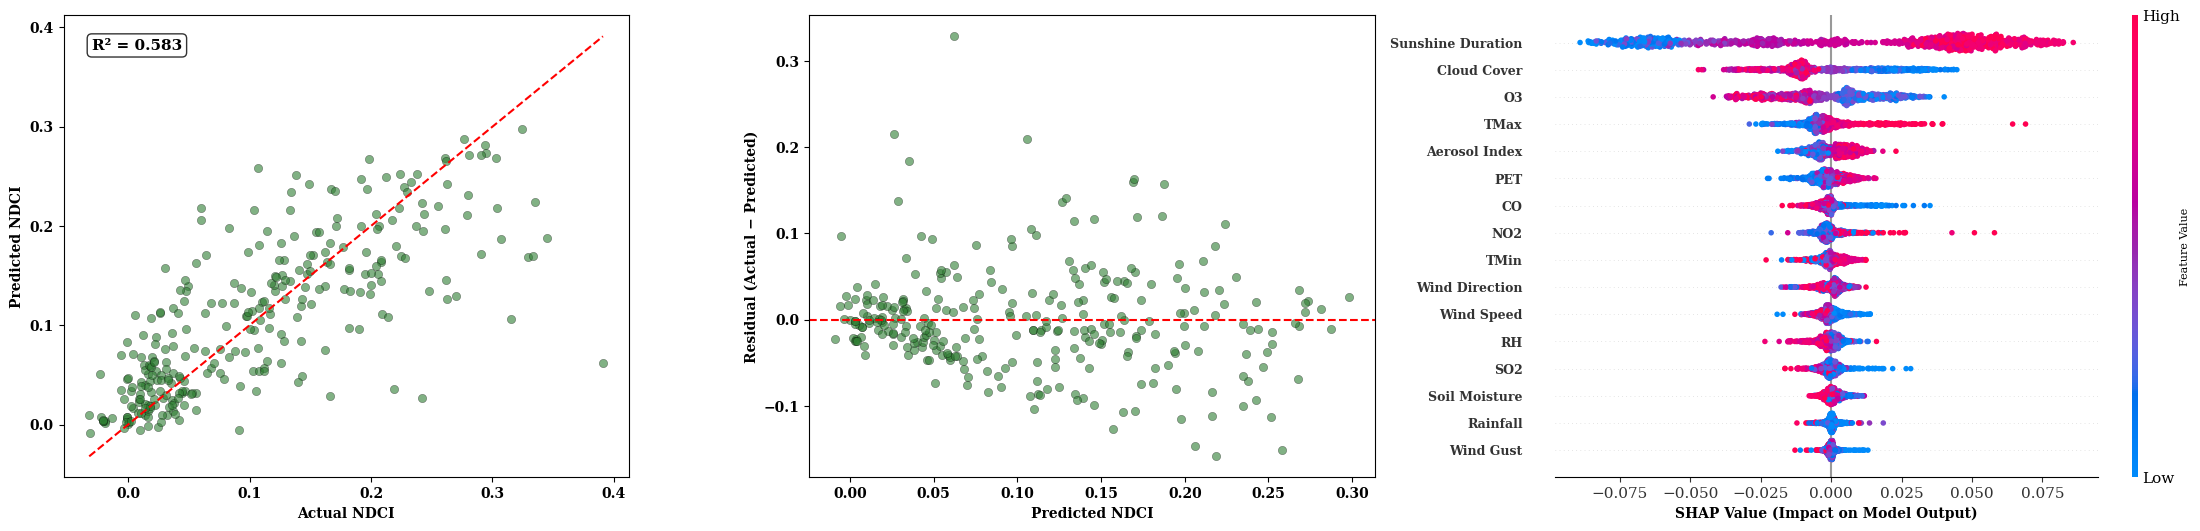

In [ ]:
plt.rcParams['font.family'] = 'serif'

fig = plt.figure(figsize=(28, 6))
gs = gridspec.GridSpec(1, 3, width_ratios=[1, 1, 1.2], wspace=0.3)
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
ax3 = fig.add_subplot(gs[2])

# Panel 1: Actual vs Predicted (title removed, R² moved into box on plot)
ax1.scatter(y_test, predictions, alpha=0.6, color='#2E7D32', edgecolor='black', linewidth=0.3)
min_val = min(y_test.min(), predictions.min())
max_val = max(y_test.max(), predictions.max())
ax1.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=1.5)
ax1.set_xlabel('Actual NDCI', fontweight='bold')
ax1.set_ylabel('Predicted NDCI', fontweight='bold')
ax1.grid(False)
ax1.text(0.05, 0.95, f'R² = {r2:.3f}', transform=ax1.transAxes,
         fontsize=11, fontweight='bold', verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Panel 2: Residuals (title removed)
residuals = y_test - predictions
ax2.scatter(predictions, residuals, alpha=0.6, color='#2E7D32', edgecolor='black', linewidth=0.3)
ax2.axhline(y=0, color='red', linestyle='--', linewidth=1.5)
ax2.set_xlabel('Predicted NDCI', fontweight='bold')
ax2.set_ylabel('Residual (Actual − Predicted)', fontweight='bold')
ax2.grid(False)

# Panel 3: SHAP Summary (title removed, mean-SHAP values removed from labels)
X_full_display_clean = X_full.copy()
X_full_display_clean.columns = [col.replace('_', ' ') for col in X_full.columns]

plt.sca(ax3)
shap.summary_plot(shap_values_full, X_full_display_clean, show=False, plot_size=None)
ax3.set_xlabel('SHAP Value (Impact on Model Output)', fontsize=10, fontweight='bold')
plt.setp(ax3.get_yticklabels(), fontweight='bold', fontsize=9)

for ax in [ax1, ax2]:
    plt.setp(ax.get_xticklabels(), fontweight='bold')
    plt.setp(ax.get_yticklabels(), fontweight='bold')

for extra_ax in fig.axes:
    if extra_ax not in (ax1, ax2, ax3):
        extra_ax.set_ylabel('Feature Value', fontsize=8)
        pos = extra_ax.get_position()
        extra_ax.set_position([pos.x0, pos.y0, pos.width * 0.8, pos.height])

plt.savefig('regression_combined_validation.png', dpi=300, bbox_inches='tight')
files.download('regression_combined_validation.png')
plt.show()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

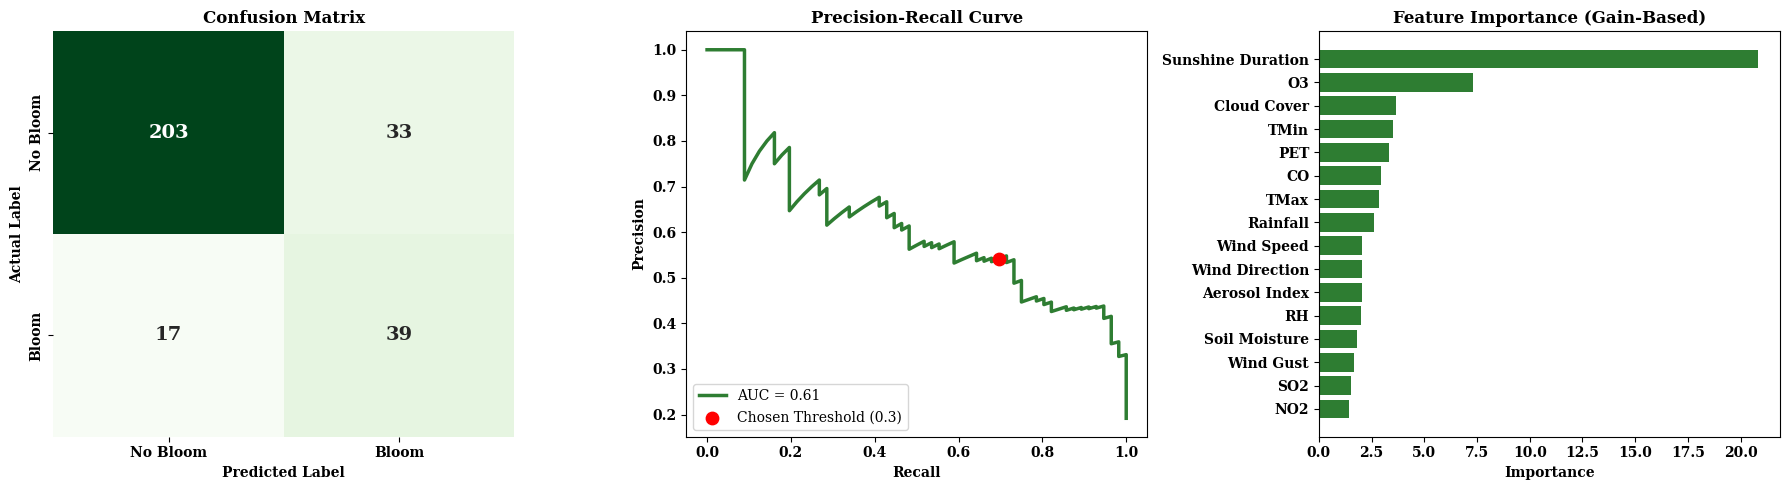

In [ ]:
plt.rcParams['font.family'] = 'serif'

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Confusion Matrix
cm = confusion_matrix(cy_test, cpred_adjusted)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['No Bloom', 'Bloom'], yticklabels=['No Bloom', 'Bloom'],
            annot_kws={'fontweight': 'bold', 'fontsize': 14}, ax=axes[0])
axes[0].set_xlabel('Predicted Label', fontweight='bold')
axes[0].set_ylabel('Actual Label', fontweight='bold')
axes[0].set_title('Confusion Matrix', fontweight='bold')

# Panel 2: Precision-Recall Curve
precision_vals, recall_vals, thresholds = precision_recall_curve(cy_test, cprob)
pr_auc = auc(recall_vals, precision_vals)
idx = (np.abs(thresholds - 0.3)).argmin()

axes[1].plot(recall_vals, precision_vals, color='#2E7D32', linewidth=2.5, label=f'AUC = {pr_auc:.2f}')
axes[1].scatter(recall_vals[idx], precision_vals[idx], color='red', s=80, zorder=5, label='Chosen Threshold (0.3)')
axes[1].set_xlabel('Recall', fontweight='bold')
axes[1].set_ylabel('Precision', fontweight='bold')
axes[1].set_title('Precision-Recall Curve', fontweight='bold')
axes[1].legend(loc='lower left')
axes[1].grid(False)

# Panel 3: Feature Importance
cimportance = cmodel.get_booster().get_score(importance_type='gain')
cimportance_df = pd.DataFrame(list(cimportance.items()), columns=['Feature', 'Importance'])
cimportance_df['Feature'] = cimportance_df['Feature'].str.replace('_', ' ')
cimportance_df = cimportance_df.sort_values('Importance', ascending=True)

axes[2].barh(cimportance_df['Feature'], cimportance_df['Importance'], color='#2E7D32')
axes[2].set_xlabel('Importance', fontweight='bold')
axes[2].set_title('Feature Importance (Gain-Based)', fontweight='bold')
axes[2].grid(False)

for ax in [axes[1], axes[2]]:
    plt.setp(ax.get_xticklabels(), fontweight='bold')
    plt.setp(ax.get_yticklabels(), fontweight='bold')
plt.setp(axes[0].get_xticklabels(), fontweight='bold')
plt.setp(axes[0].get_yticklabels(), fontweight='bold')

plt.tight_layout()
plt.savefig('classification_combined_validation.png', dpi=300, bbox_inches='tight')
files.download('classification_combined_validation.png')
plt.show()

In [ ]:
RANDOM_SEED = 42

bloom_rows = hsl[hsl['Bloom'] == 1]
nonbloom_rows = hsl[hsl['Bloom'] == 0]

print(f"Available bloom observations: {len(bloom_rows)}")
print(f"Available non-bloom observations: {len(nonbloom_rows)}")

n_bloom = min(160, len(bloom_rows))
bloom_sample = bloom_rows.sample(n=n_bloom, random_state=RANDOM_SEED)
nonbloom_sample = nonbloom_rows.sample(n=160, random_state=RANDOM_SEED)

balanced_hsl = pd.concat([bloom_sample, nonbloom_sample]).sort_values('Date').reset_index(drop=True)
print("\nBalanced set total:", balanced_hsl['Bloom'].value_counts().to_dict())

btrain = balanced_hsl[balanced_hsl['Date'] < '2024-01-01']
btest = balanced_hsl[balanced_hsl['Date'] >= '2024-01-01']

print("\nTrain class balance:", btrain['Bloom'].value_counts().to_dict())
print("Test class balance:", btest['Bloom'].value_counts().to_dict())

bcx_train = btrain.drop(columns=['Date','NDCI','NDTI','SDD','Bloom','Prediction'], errors='ignore')
bcy_train = btrain['Bloom']
bcx_test = btest.drop(columns=['Date','NDCI','NDTI','SDD','Bloom','Prediction'], errors='ignore')
bcy_test = btest['Bloom']

from xgboost import XGBClassifier

bcmodel = XGBClassifier(n_estimators=100, learning_rate=.1, random_state=RANDOM_SEED)
bcmodel.fit(bcx_train, bcy_train)

bcprob = bcmodel.predict_proba(bcx_test)[:, 1]
bcpred = (bcprob >= 0.5).astype(int)  # revisit threshold now that classes are balanced

print(classification_report(bcy_test, bcpred))

Available bloom observations: 160
Available non-bloom observations: 708

Balanced set total: {0: 160, 1: 160}

Train class balance: {0: 113, 1: 104}
Test class balance: {1: 56, 0: 47}
              precision    recall  f1-score   support

           0       0.72      0.77      0.74        47
           1       0.79      0.75      0.77        56

    accuracy                           0.76       103
   macro avg       0.76      0.76      0.76       103
weighted avg       0.76      0.76      0.76       103



In [ ]:
# RANDOM_SEED = 42

# bloom_rows = hsl[hsl['Bloom'] == 1]
# nonbloom_rows = hsl[hsl['Bloom'] == 0]

# bloom_sample = bloom_rows.sample(n=min(160, len(bloom_rows)), random_state=RANDOM_SEED)
# nonbloom_sample = nonbloom_rows.sample(n=160, random_state=RANDOM_SEED)

# balanced_hsl = pd.concat([bloom_sample, nonbloom_sample]).sort_values('Date').reset_index(drop=True)

# btrain = balanced_hsl[balanced_hsl['Date'] < '2024-01-01']
# btest = balanced_hsl[balanced_hsl['Date'] >= '2024-01-01']

# drop_cols = ['Date', 'NDCI', 'NDTI', 'SDD', 'Bloom', 'Prediction']
# bcx_train = btrain.drop(columns=drop_cols, errors='ignore')
# bcy_train = btrain['Bloom']
# bcx_test = btest.drop(columns=drop_cols, errors='ignore')
# bcy_test = btest['Bloom']

# bcmodel = XGBClassifier(n_estimators=100, learning_rate=.1, random_state=RANDOM_SEED)
# bcmodel.fit(bcx_train, bcy_train)

# bcprob = bcmodel.predict_proba(bcx_test)[:, 1]
# bcpred = (bcprob >= 0.5).astype(int)

# bcm = confusion_matrix(bcy_test, bcpred)
# bprecision_vals, brecall_vals, bthresholds = precision_recall_curve(bcy_test, bcprob)
# bpr_auc = auc(brecall_vals, bprecision_vals)

# bcexplainer = shap.TreeExplainer(bcmodel)
# bcshap_values = bcexplainer.shap_values(bcx_test)
# bcx_test_display = bcx_test.copy()
# bcx_test_display.columns = [col.replace('_', ' ') for col in bcx_test_display.columns]

# plt.rcParams['font.family'] = 'serif'

# fig = plt.figure(figsize=(28, 6))
# gs = gridspec.GridSpec(1, 3, width_ratios=[1, 1, 1.2], wspace=0.3)

# ax1 = fig.add_subplot(gs[0])
# ax2 = fig.add_subplot(gs[1])
# ax3 = fig.add_subplot(gs[2])

# sns.heatmap(bcm, annot=True, fmt='d', cmap='Greens', cbar=False,
#             xticklabels=['No Bloom', 'Bloom'], yticklabels=['No Bloom', 'Bloom'],
#             annot_kws={'fontweight': 'bold', 'fontsize': 14}, ax=ax1)
# ax1.set_xlabel('Predicted Label', fontweight='bold')
# ax1.set_ylabel('Actual Label', fontweight='bold')
# ax1.set_title('Confusion Matrix', fontweight='bold', loc='left')
# plt.setp(ax1.get_xticklabels(), fontweight='bold')
# plt.setp(ax1.get_yticklabels(), fontweight='bold')

# ax2.plot(brecall_vals, bprecision_vals, color='#2E7D32', linewidth=2.5,
#          label=f'PR Curve (AUC = {bpr_auc:.2f})')
# idx = (np.abs(bthresholds - 0.5)).argmin()
# ax2.scatter(brecall_vals[idx], bprecision_vals[idx], color='red', s=80, zorder=5,
#             label='Chosen Threshold (0.5)')
# ax2.set_xlabel('Recall', fontweight='bold')
# ax2.set_ylabel('Precision', fontweight='bold')
# ax2.set_title('Precision-Recall Curve', fontweight='bold', loc='left')
# ax2.legend(loc='lower left')
# ax2.grid(False)
# plt.setp(ax2.get_xticklabels(), fontweight='bold')
# plt.setp(ax2.get_yticklabels(), fontweight='bold')

# plt.sca(ax3)
# shap.summary_plot(bcshap_values, bcx_test_display, show=False, plot_size=None)
# ax3.set_title('SHAP Summary', fontweight='bold', loc='left', fontsize=13)
# ax3.set_xlabel('SHAP Value (Impact on Model Output)', fontsize=10)
# plt.setp(ax3.get_yticklabels(), fontweight='bold', fontsize=9)

# for extra_ax in fig.axes:
#     if extra_ax not in (ax1, ax2, ax3):
#         extra_ax.set_ylabel('Feature Value', fontsize=8)
#         pos = extra_ax.get_position()
#         extra_ax.set_position([pos.x0, pos.y0, pos.width * 0.4, pos.height])

# plt.savefig('balanced_classification_full_validation.png', dpi=300, bbox_inches='tight')
# plt.show()

# print(classification_report(bcy_test, bcpred))

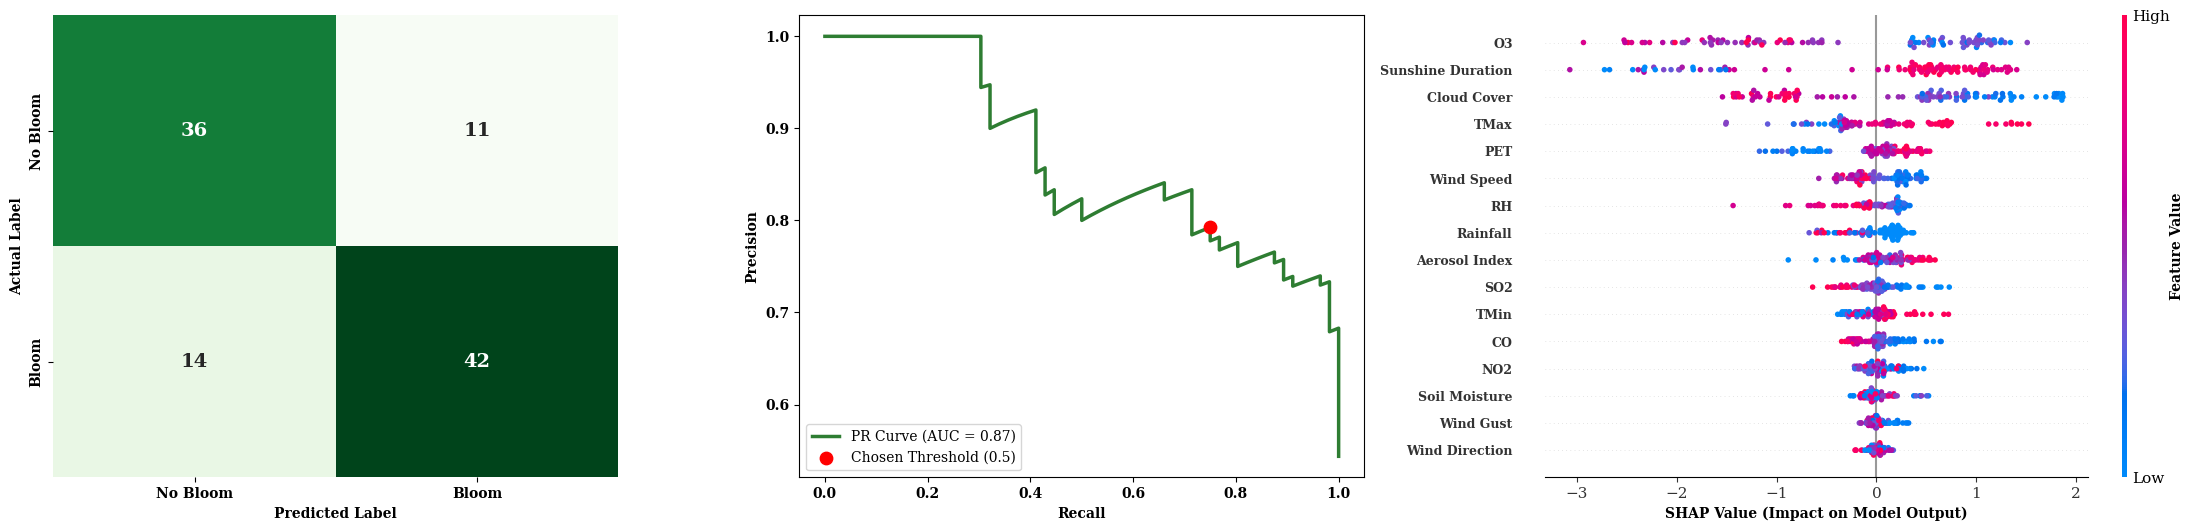

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import shap
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, precision_recall_curve, auc, classification_report

RANDOM_SEED = 42

# Rebuild balanced dataset
bloom_rows = hsl[hsl['Bloom'] == 1]
nonbloom_rows = hsl[hsl['Bloom'] == 0]
bloom_sample = bloom_rows.sample(n=min(160, len(bloom_rows)), random_state=RANDOM_SEED)
nonbloom_sample = nonbloom_rows.sample(n=160, random_state=RANDOM_SEED)
balanced_hsl = pd.concat([bloom_sample, nonbloom_sample]).sort_values('Date').reset_index(drop=True)

btrain = balanced_hsl[balanced_hsl['Date'] < '2024-01-01']
btest = balanced_hsl[balanced_hsl['Date'] >= '2024-01-01']
drop_cols = ['Date', 'NDCI', 'NDTI', 'SDD', 'Bloom', 'Prediction']
bcx_train = btrain.drop(columns=drop_cols, errors='ignore')
bcy_train = btrain['Bloom']
bcx_test = btest.drop(columns=drop_cols, errors='ignore')
bcy_test = btest['Bloom']

# Original untuned model
bcmodel = XGBClassifier(n_estimators=100, learning_rate=.1, random_state=RANDOM_SEED)
bcmodel.fit(bcx_train, bcy_train)

bcprob = bcmodel.predict_proba(bcx_test)[:, 1]
bcpred = (bcprob >= 0.5).astype(int)

bcm = confusion_matrix(bcy_test, bcpred)
bprecision_vals, brecall_vals, bthresholds = precision_recall_curve(bcy_test, bcprob)
bpr_auc = auc(brecall_vals, bprecision_vals)

bcexplainer = shap.TreeExplainer(bcmodel)
bcshap_values = bcexplainer.shap_values(bcx_test)
bcx_test_display_clean = bcx_test.copy()
bcx_test_display_clean.columns = [col.replace('_', ' ') for col in bcx_test.columns]

# Combined figure
plt.rcParams['font.family'] = 'serif'
fig = plt.figure(figsize=(28, 6))
gs = gridspec.GridSpec(1, 3, width_ratios=[1, 1, 1.2], wspace=0.3)
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
ax3 = fig.add_subplot(gs[2])

# Panel 1: Confusion Matrix
sns.heatmap(bcm, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['No Bloom', 'Bloom'], yticklabels=['No Bloom', 'Bloom'],
            annot_kws={'fontweight': 'bold', 'fontsize': 14}, ax=ax1)
ax1.set_xlabel('Predicted Label', fontweight='bold')
ax1.set_ylabel('Actual Label', fontweight='bold')
plt.setp(ax1.get_xticklabels(), fontweight='bold')
plt.setp(ax1.get_yticklabels(), fontweight='bold')

# Panel 2: Precision-Recall Curve
ax2.plot(brecall_vals, bprecision_vals, color='#2E7D32', linewidth=2.5, label=f'PR Curve (AUC = {bpr_auc:.2f})')
idx = (np.abs(bthresholds - 0.5)).argmin()
ax2.scatter(brecall_vals[idx], bprecision_vals[idx], color='red', s=80, zorder=5, label='Chosen Threshold (0.5)')
ax2.set_xlabel('Recall', fontweight='bold')
ax2.set_ylabel('Precision', fontweight='bold')
ax2.legend(loc='lower left')
ax2.grid(False)
plt.setp(ax2.get_xticklabels(), fontweight='bold')
plt.setp(ax2.get_yticklabels(), fontweight='bold')

# Panel 3: SHAP Summary
plt.sca(ax3)
shap.summary_plot(bcshap_values, bcx_test_display_clean, show=False, plot_size=None)
ax3.set_xlabel('SHAP Value (Impact on Model Output)', fontsize=10, fontweight='bold')
plt.setp(ax3.get_yticklabels(), fontweight='bold', fontsize=9)

for extra_ax in fig.axes:
    if extra_ax not in (ax1, ax2, ax3):
        extra_ax.set_ylabel('Feature Value', fontsize=10, fontweight='bold')
        pos = extra_ax.get_position()
        extra_ax.set_position([pos.x0, pos.y0, pos.width * 0.8, pos.height])

plt.savefig('balanced_classification_full_validation.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import matplotlib.gridspec as gridspec
# import seaborn as sns
# import shap
# from xgboost import XGBClassifier
# from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
# from sklearn.metrics import (confusion_matrix, precision_recall_curve, auc,
#                               classification_report, accuracy_score, f1_score,
#                               precision_score, recall_score)

# RANDOM_SEED = 42

# # Rebuild balanced dataset
# bloom_rows = hsl[hsl['Bloom'] == 1]
# nonbloom_rows = hsl[hsl['Bloom'] == 0]
# bloom_sample = bloom_rows.sample(n=min(160, len(bloom_rows)), random_state=RANDOM_SEED)
# nonbloom_sample = nonbloom_rows.sample(n=160, random_state=RANDOM_SEED)
# balanced_hsl = pd.concat([bloom_sample, nonbloom_sample]).sort_values('Date').reset_index(drop=True)

# btrain = balanced_hsl[balanced_hsl['Date'] < '2024-01-01']
# btest = balanced_hsl[balanced_hsl['Date'] >= '2024-01-01']
# drop_cols = ['Date', 'NDCI', 'NDTI', 'SDD', 'Bloom', 'Prediction']
# bcx_train = btrain.drop(columns=drop_cols, errors='ignore')
# bcy_train = btrain['Bloom']
# bcx_test = btest.drop(columns=drop_cols, errors='ignore')
# bcy_test = btest['Bloom']

# # Hyperparameter search
# param_dist = {
#     'max_depth': [3, 4, 5, 6, 7],
#     'min_child_weight': [1, 3, 5, 7],
#     'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
#     'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
#     'learning_rate': [0.01, 0.05, 0.1, 0.15, 0.2],
#     'n_estimators': [50, 100, 150, 200]
# }

# search = RandomizedSearchCV(XGBClassifier(random_state=RANDOM_SEED), param_distributions=param_dist,
#                              n_iter=50, scoring='f1', cv=5, random_state=RANDOM_SEED, n_jobs=-1, verbose=1)
# search.fit(bcx_train, bcy_train)
# print("Best params:", search.best_params_)

# bcmodel = search.best_estimator_

# # Test set predictions from tuned model
# bcprob = bcmodel.predict_proba(bcx_test)[:, 1]
# bcpred = (bcprob >= 0.5).astype(int)
# bcm = confusion_matrix(bcy_test, bcpred)
# bprecision_vals, brecall_vals, bthresholds = precision_recall_curve(bcy_test, bcprob)
# bpr_auc = auc(brecall_vals, bprecision_vals)

# print("Tuned model test accuracy:", accuracy_score(bcy_test, bcpred))
# print(classification_report(bcy_test, bcpred))

# # Time-series CV stability check on tuned params
# bx_full = balanced_hsl.drop(columns=drop_cols, errors='ignore')
# by_full = balanced_hsl['Bloom']
# tscv = TimeSeriesSplit(n_splits=5)
# acc_scores, f1_scores, prec_scores, rec_scores = [], [], [], []

# for fold, (train_idx, test_idx) in enumerate(tscv.split(bx_full), start=1):
#     X_tr, X_te = bx_full.iloc[train_idx], bx_full.iloc[test_idx]
#     y_tr, y_te = by_full.iloc[train_idx], by_full.iloc[test_idx]
#     fold_model = XGBClassifier(**search.best_params_, random_state=RANDOM_SEED)
#     fold_model.fit(X_tr, y_tr)
#     fold_pred = fold_model.predict(X_te)
#     acc_scores.append(accuracy_score(y_te, fold_pred))
#     f1_scores.append(f1_score(y_te, fold_pred, zero_division=0))
#     prec_scores.append(precision_score(y_te, fold_pred, zero_division=0))
#     rec_scores.append(recall_score(y_te, fold_pred, zero_division=0))
#     print(f"Fold {fold}: Accuracy={acc_scores[-1]:.3f}, F1={f1_scores[-1]:.3f}, "
#           f"Precision={prec_scores[-1]:.3f}, Recall={rec_scores[-1]:.3f}")

# print(f"\nCV Accuracy:  {np.mean(acc_scores):.3f} ± {np.std(acc_scores):.3f}")
# print(f"CV F1:        {np.mean(f1_scores):.3f} ± {np.std(f1_scores):.3f}")
# print(f"CV Precision: {np.mean(prec_scores):.3f} ± {np.std(prec_scores):.3f}")
# print(f"CV Recall:    {np.mean(rec_scores):.3f} ± {np.std(rec_scores):.3f}")

# # SHAP on tuned model, test set
# bcexplainer = shap.TreeExplainer(bcmodel)
# bcshap_values = bcexplainer.shap_values(bcx_test)
# bcx_test_display = bcx_test.copy()
# bcx_test_display.columns = [col.replace('_', ' ') for col in bcx_test_display.columns]

# # Combined figure: confusion matrix, PR curve, SHAP summary
# plt.rcParams['font.family'] = 'serif'
# fig = plt.figure(figsize=(28, 6))
# gs = gridspec.GridSpec(1, 3, width_ratios=[1, 1, 1.2], wspace=0.3)
# ax1 = fig.add_subplot(gs[0])
# ax2 = fig.add_subplot(gs[1])
# ax3 = fig.add_subplot(gs[2])

# sns.heatmap(bcm, annot=True, fmt='d', cmap='Greens', cbar=False,
#             xticklabels=['No Bloom', 'Bloom'], yticklabels=['No Bloom', 'Bloom'],
#             annot_kws={'fontweight': 'bold', 'fontsize': 14}, ax=ax1)
# ax1.set_xlabel('Predicted Label', fontweight='bold')
# ax1.set_ylabel('Actual Label', fontweight='bold')
# ax1.set_title('Confusion Matrix', fontweight='bold', loc='left')
# plt.setp(ax1.get_xticklabels(), fontweight='bold')
# plt.setp(ax1.get_yticklabels(), fontweight='bold')

# ax2.plot(brecall_vals, bprecision_vals, color='#2E7D32', linewidth=2.5, label=f'PR Curve (AUC = {bpr_auc:.2f})')
# idx = (np.abs(bthresholds - 0.5)).argmin()
# ax2.scatter(brecall_vals[idx], bprecision_vals[idx], color='red', s=80, zorder=5, label='Chosen Threshold (0.5)')
# ax2.set_xlabel('Recall', fontweight='bold')
# ax2.set_ylabel('Precision', fontweight='bold')
# ax2.set_title('Precision-Recall Curve', fontweight='bold', loc='left')
# ax2.legend(loc='lower left')
# ax2.grid(False)
# plt.setp(ax2.get_xticklabels(), fontweight='bold')
# plt.setp(ax2.get_yticklabels(), fontweight='bold')

# plt.sca(ax3)
# shap.summary_plot(bcshap_values, bcx_test_display, show=False, plot_size=None)
# ax3.set_title('SHAP Summary', fontweight='bold', loc='left', fontsize=13)
# ax3.set_xlabel('SHAP Value (Impact on Model Output)', fontsize=10)
# plt.setp(ax3.get_yticklabels(), fontweight='bold', fontsize=9)

# for extra_ax in fig.axes:
#     if extra_ax not in (ax1, ax2, ax3):
#         extra_ax.set_ylabel('Feature Value', fontsize=8)
#         pos = extra_ax.get_position()
#         extra_ax.set_position([pos.x0, pos.y0, pos.width * 0.4, pos.height])

# plt.savefig('tuned_balanced_classification_full_validation.png', dpi=300, bbox_inches='tight')
# plt.show()

after testing with hypertuning and cross validation it was found that these tools actually made the model much worse. We will continue to stick with the original make.

In [ ]:
# plt.rcParams['font.family'] = 'serif'

# metrics = ['Accuracy', 'Recall (Bloom)', 'Precision (Bloom)', 'PR-AUC']
# original_scores = [0.757, 0.75, 0.79, 0.87]
# tuned_scores = [0.748, 0.68, 0.83, 0.84]

# x = np.arange(len(metrics))
# width = 0.35

# fig, ax = plt.subplots(figsize=(9, 6))

# bars1 = ax.bar(x - width/2, original_scores, width, label='Original Balanced', color='#A5D6A7', edgecolor='black', linewidth=0.5)
# bars2 = ax.bar(x + width/2, tuned_scores, width, label='Tuned', color='#2E7D32', edgecolor='black', linewidth=0.5)

# for bars in [bars1, bars2]:
#     for bar in bars:
#         height = bar.get_height()
#         ax.annotate(f'{height:.2f}', xy=(bar.get_x() + bar.get_width()/2, height),
#                     xytext=(0, 3), textcoords='offset points',
#                     ha='center', fontweight='bold', fontsize=9)

# # ax.set_xticks(x)
# ax.set_xticklabels(metrics, fontweight='bold')
# ax.set_ylabel('Score', fontweight='bold')
# ax.set_title('Classification Model Comparison: Original vs. Tuned', fontweight='bold', loc='left')
# ax.set_ylim(0, 1.05)
# ax.legend(loc='lower right')
# ax.grid(False)

# plt.setp(ax.get_yticklabels(), fontweight='bold')

# plt.savefig('classification_model_comparison.png', dpi=300, bbox_inches='tight')
# plt.show()